# 02 — Introduction to Machine Learning

**Prerequisite:** notebook 01. **Theory used:** §0, §6.

## What you'll be able to do after this notebook

1. Explain *in your own words* what ML is — and what it isn't.
2. Tell apart **supervised**, **unsupervised**, and **reinforcement** learning,
 and know which to reach for.
3. Understand why we split data into **train / validation / test** sets and what
 goes wrong if we don't (the bias–variance trade‑off, §6).
4. Train a baseline model and evaluate it honestly with **cross‑validation**.
5. Recognise **data leakage** — the #1 cause of "too good to be true" scores —
 and the failure case at the end shows it biting.

## 1. What machine learning actually is

Conventional programming: you write the **rules**, the computer applies them to
**data**, and you get **answers**.

```mermaid
flowchart LR
 R["Rules"] --> A["Answers"]
 D["Data"] --> A
```

Machine learning flips the arrow. You feed the computer **data** and the
**answers**, and it figures out the **rules**:

```mermaid
flowchart LR
 D["Data"] --> R["Rules"]
 A["Answers"] --> R
```

That learned set of rules is called a **model** — a function you feed a new
input to get a prediction.

> **Rule of thumb:** if you could write the logic by hand with a long `if/else`,
> you might not need ML. You reach for ML when the pattern is too messy, too
> high‑dimensional, or too subtle to hand‑code — but it's still there in the
> data.

### When ML is the wrong tool

- You have very little data (models learn nothing reliable).
- The cost of a wrong prediction is catastrophic and you can't tolerate any
 error (use hard rules + humans).
- The relationship is genuinely simple and a formula already exists.
- You can't define what "correct" looks like.

## 2. The three flavours of learning

| Paradigm | What you give it | What it produces | Example question |
|---|---|---|---|
| **Supervised** | data **+ labels** | a predictor | "Will this customer churn?" |
| **Unsupervised** | data only | structure / groups | "What segments exist in my users?" |
| **Reinforcement** | an agent + rewards | a policy | "How should a robot move to maximise score?" |

This handbook covers **supervised** (notebooks 04–10) and **unsupervised**
(11–12) in depth. Reinforcement is sketched below — it needs its own course.

### Supervised, more precisely

You have a table where each row has **features** (`X`) and a **target** (`y`).
The target is either:

- a **number** → **regression** (predict house price, temperature, revenue)
- a **category** → **classification** (predict churn yes/no, disease type, spam)

That single distinction — *is `y` a number or a category?* — decides most of
your modelling choices.

### Unsupervised, more precisely

There are no labels. You're asking the data to organise itself:

- **Clustering** (notebook 12): group similar rows together.
- **Dimensionality reduction** (notebook 11, PCA): squash many correlated
 features into a few informative ones.

### Reinforcement learning — one paragraph

An **agent** takes **actions** in an **environment**, receives **rewards**, and
learns a **policy** (states → actions) that maximises long‑term reward. Think
game‑playing AI, robotics, recommendation tuning. Algorithms: Q‑learning,
policy gradients, actor‑critic. Out of scope here, but useful vocabulary.

> **Vocabulary watch (§0):** note that "supervised/unsupervised" use
> "independent variables" to mean *features* — which does **not** mean those
> features are statistically *independent* of each other (they rarely are).
> Two different meanings of "independent" — the classic collision.

## 3. The supervised learning loop

```mermaid
flowchart TD
 R["Raw data"] --> C["Clean & engineer features<br/><small>notebook 03</small>"]
 C --> S["Split: train / val / test"]
 S --> F["Fit a model on train"]
 F --> V["Evaluate on validation"]
 V -- "tune hyperparameters, repeat" --> F
 V --> T["Final score on test<br/><small>touched ONCE, at the very end</small>"]
```

The single most important habit in this diagram: **the test set is touched
exactly once, at the very end.** Everything else — feature engineering, model
choice, hyperparameter tuning — happens on train + validation only. The failure
case in §8 shows what happens when you break this rule.

## 4. Why we split: the overfitting story (§6)

If you train and evaluate a model on the **same** data, you reward it for
*memorising*. A flexible enough model (a deep tree, a high‑degree polynomial)
can fit any training set perfectly — and then fail completely on new data.

**Overfitting** (high *variance*, §6.1) = the model learned the training
data *and its noise*, not the underlying signal. **Underfitting** (high *bias*)
= the model is too simple to capture the signal at all. The cure is honest
evaluation: hold out data the model never saw, and score it there.

> **Watch the words (§0, §6.1):** "bias" and "variance" here are the
> *ML/CS* meanings (model error, model sensitivity) — **not** the data‑spread
> variance of §1.2. Same words, three related ideas. This is exactly the
> collision the reference flags.

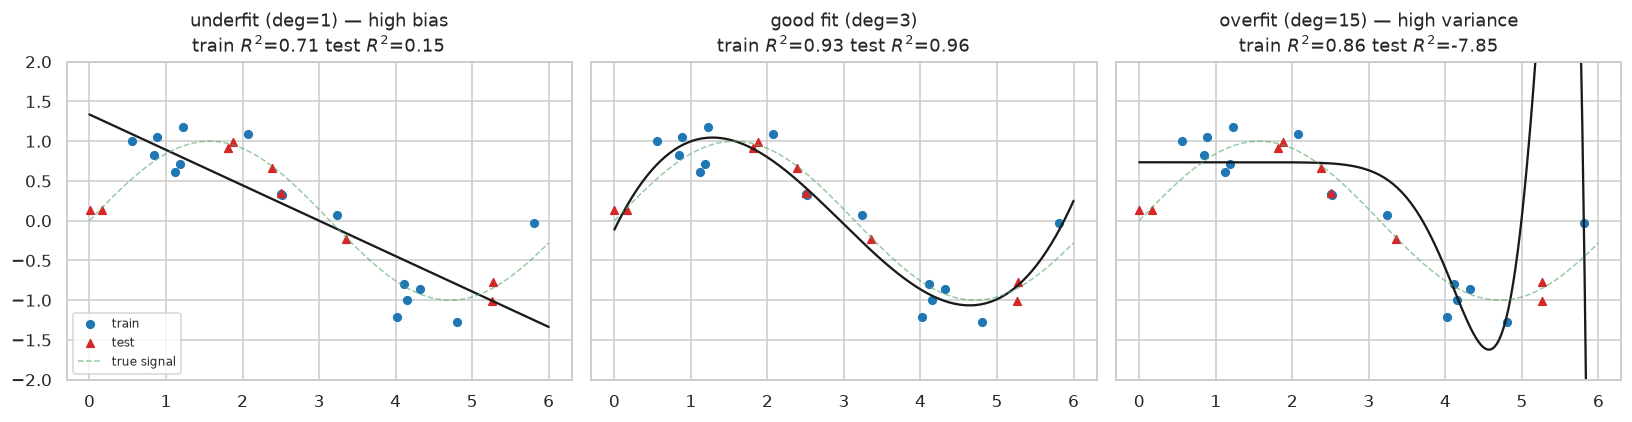

In [1]:
# Shared setup: numpy/pandas/sklearn/matplotlib/seaborn + plotting defaults
# + clean-output warning suppression. See setup.py for details.
from setup import *

# Demonstrate overfitting visually with a simple 1D example.
# True signal: a gentle sine wave + noise
rng = np.random.RandomState(1)
x = np.sort(rng.uniform(0, 6, 25))
y_true = np.sin(x)
y = y_true + rng.normal(0, 0.25, size=len(x))

X_train, X_test, y_train, y_test = train_test_split(
 x[:, None], y, test_size=0.33, random_state=42
)
xs = np.linspace(0, 6, 200)[:, None]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, deg, title in zip(axes, [1, 3, 15],
 ["underfit (deg=1) — high bias",
 "good fit (deg=3)",
 "overfit (deg=15) — high variance"]):
 model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
 model.fit(X_train, y_train)
 train_score = model.score(X_train, y_train)
 test_score = model.score(X_test, y_test)
 ax.scatter(X_train.ravel(), y_train, c="tab:blue", label="train", s=25)
 ax.scatter(X_test.ravel(), y_test, c="tab:red", label="test", s=25, marker="^")
 ax.plot(xs, model.predict(xs), "k-", lw=1.5)
 ax.plot(xs, np.sin(xs), "g--", lw=1, alpha=0.6, label="true signal")
 ax.set_title(f"{title}\ntrain $R^2$={train_score:.2f} test $R^2$={test_score:.2f}")
 ax.set_ylim(-2, 2)
axes[0].legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()

**How to read the three panels (the whole bias–variance story in one figure):**

- **Left (degree 1, high bias):** a straight line can't capture a sine wave.
 Bad on train *and* test — the model is too simple. This is *underfitting*.
- **Middle (degree 3, sweet spot):** captures the wave, ignores the noise. Test
 $R^2$ is highest here.
- **Right (degree 15, high variance):** the curve passes through every blue
 training point but goes wild between them. Train $R^2$ ≈ 1.0, test $R^2$
 collapses — the model *memorised* the noise. This is *overfitting*.

> **The pattern to internalise:** as complexity rises, training score keeps
> climbing; test score rises, peaks, then falls. Your job is to find the peak.

## 5. Worked example A — first real model on the CEO dataset

Goal: predict `Stock_Market` (Yes/No) — a **binary classification** problem.
We reuse the pipeline pattern from notebook 01, but this time focus on the
*evaluation*.

In [2]:
from pathlib import Path
import pandas as pd

ceo = pd.read_csv(Path("data/ceo_data.csv"))
X = ceo.drop(columns=["Stock_Market"])
y = (ceo["Stock_Market"] == "Yes").astype(int) # 1=Yes, 0=No

balance = y.value_counts(normalize=True).rename(index={0:"No", 1:"Yes"}).round(3)
print("Target balance:")
print(balance)
print(f"\nBaseline (always guess the majority class 'Yes'): {y.mean():.1%}")

Target balance:
Stock_Market
Yes    0.7
No     0.3
Name: proportion, dtype: float64

Baseline (always guess the majority class 'Yes'): 70.0%


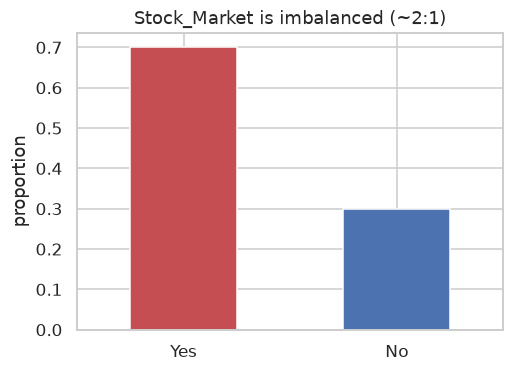

In [3]:
# Visualise the target balance — always look before you model.
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 3.5))
balance.plot(kind="bar", color=["#c44e52", "#4c72b0"], ax=ax)
ax.set_title("Stock_Market is imbalanced (~2:1)")
ax.set_ylabel("proportion"); ax.set_xlabel("")
plt.xticks(rotation=0)
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.25, random_state=42, stratify=y
)

cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
pre = ColumnTransformer([
 ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
], remainder="passthrough")

pipe = Pipeline([
 ("pre", pre),
 ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
])
pipe.fit(X_train, y_train)

pred = pipe.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, pred):.2%}")
print(f"Baseline (guess Yes): {y_test.mean():.2%}")
print()
print(classification_report(y_test, pred, target_names=["No", "Yes"]))

Accuracy: 60.00%
Baseline (guess Yes): 73.33%

              precision    recall  f1-score   support

          No       0.38      0.75      0.50         4
         Yes       0.86      0.55      0.67        11

    accuracy                           0.60        15
   macro avg       0.62      0.65      0.58        15
weighted avg       0.73      0.60      0.62        15



**Reading the report:**
- **Precision** = of the rows we *predicted* Yes, how many really were Yes.
- **Recall** = of the rows that *really are* Yes, how many did we catch.
- **F1** = their harmonic mean (use when classes are imbalanced, §5).

With only ~45 training rows on a 60‑row dataset, do not over‑interpret the
numbers — the point is the *procedure*. Notebook 05 shows how cross‑validation
and the right metric make these numbers trustworthy.

## 6. Worked example B — iris, the "hello world" of ML

The CEO data is small and mostly categorical. Let's see the *same workflow* on
the canonical iris dataset (150 flowers, 4 numeric measurements, 3 species) — a
clean, well‑behaved classification problem.

In [5]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier

iris = load_iris(as_frame=True)
X_i, y_i = iris.data, iris.target
print("Features:", list(X_i.columns))
print("Classes: ", list(iris.target_names))
X_i.head()

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes:  [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


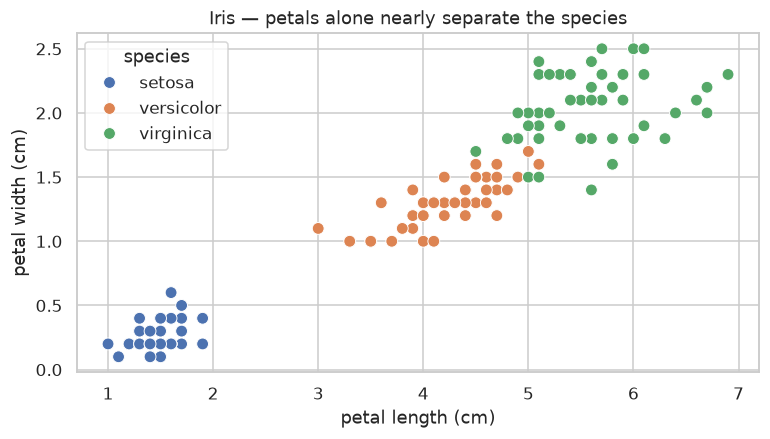

In [6]:
# A 2D peek: petal length vs petal width, coloured by species.
df_iris = X_i.copy()
df_iris["species"] = y_i.map({i: n for i, n in enumerate(iris.target_names)})
sns.scatterplot(
 data=df_iris, x="petal length (cm)", y="petal width (cm)",
 hue="species", palette="deep", s=60,
)
plt.title("Iris — petals alone nearly separate the species")
plt.show()

**What the scatter tells you before any model runs:** the three species form
three nearly disjoint clusters in petal‑space. That's a strong hint a simple
distance‑based model (like k‑NN, notebook 06) will do well here. Always look for
this kind of separability first — it tells you how hard the problem is.

In [7]:
# Same pattern as before: split -> pipeline -> fit -> score.
X_tr, X_te, y_tr, y_te = train_test_split(X_i, y_i, test_size=0.3,
 random_state=42, stratify=y_i)
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_tr, y_tr)
print(f"k-NN test accuracy on iris: {model.score(X_te, y_te):.2%}")

k-NN test accuracy on iris: 97.78%


## 7. Cross‑validation: a more honest score

A single train/test split is noisy — the number you get depends on *which* rows
landed in the test set. **k‑fold cross‑validation** fixes this:

1. Split the data into $k$ equal folds (typically 5 or 10).
2. Train on $k{-}1$ folds, evaluate on the held‑out fold.
3. Repeat $k$ times, each fold taking a turn as the test set.
4. Average the $k$ scores (and report their spread).

You get a mean score **and** a sense of how stable it is.

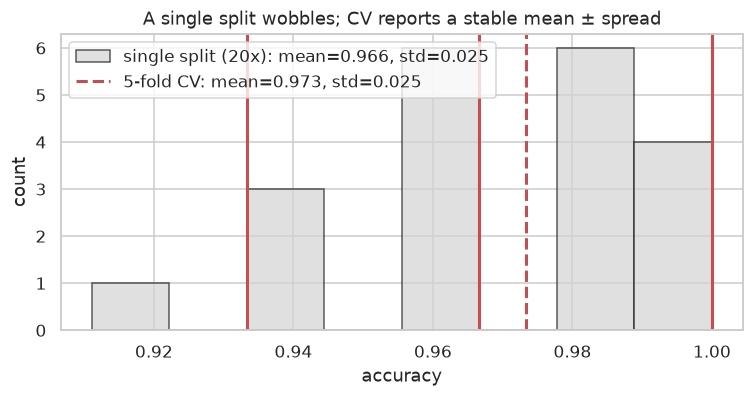

In [8]:
from sklearn.model_selection import cross_val_score

# Visualise the variance of a single split vs CV.
# Run the SAME iris model with many different single splits, then one 5-fold CV.
single = []
for rs in range(20):
 Xa, Xb, ya, yb = train_test_split(X_i, y_i, test_size=0.3, random_state=rs, stratify=y_i)
 m = KNeighborsClassifier(n_neighbors=5).fit(Xa, ya)
 single.append(m.score(Xb, yb))

cv5 = cross_val_score(KNeighborsClassifier(n_neighbors=5), X_i, y_i, cv=5)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(single, bins=8, color="lightgrey", edgecolor="k", alpha=0.7,
 label=f"single split (20x): mean={np.mean(single):.3f}, std={np.std(single):.3f}")
for s in cv5:
 ax.axvline(s, color="#c44e52", lw=2)
ax.axvline(cv5.mean(), color="#c44e52", ls="--", lw=2,
 label=f"5-fold CV: mean={cv5.mean():.3f}, std={cv5.std():.3f}")
ax.set_xlabel("accuracy"); ax.set_ylabel("count")
ax.set_title("A single split wobbles; CV reports a stable mean ± spread")
ax.legend()
plt.show()

In [9]:
# Compare three models with CV — much more trustworthy than a single split each.
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

models = {
 "logreg": LogisticRegression(max_iter=200),
 "knn-5": KNeighborsClassifier(n_neighbors=5),
 "tree": DecisionTreeClassifier(random_state=42),
}
for name, m in models.items():
 s = cross_val_score(m, X_i, y_i, cv=5)
 print(f"{name:<8} {s.mean():.3f} ± {s.std():.3f}")

logreg   0.973 ± 0.025
knn-5    0.973 ± 0.025
tree     0.953 ± 0.034


**The takeaway:** report mean **and** spread, never a bare score. "AUC = 0.91"
is a weaker statement than "AUC = 0.91 ± 0.02 across 5 folds" (§5 on why the
spread matters for decisions).

## 8. Failure case — the "too good to be true" score (data leakage)

This is the most important section. A model that scores near‑perfect on the test
set is **almost never** a great model — it's usually **leaking** information
from test into train. We'll construct the two common flavours and watch the
score betray itself.

### Flavour 1: duplicate rows across the split

If the same entity appears in both train and test (e.g. the same customer, or a
duplicated row), the model doesn't *generalise* — it *recognises*.

In [10]:
# Build a dataset where 30% of rows are exact duplicates.
rng = np.random.RandomState(0)
n_unique = 200
Xu = rng.normal(size=(n_unique, 5))
yu = (Xu[:, 0] + 0.5 * Xu[:, 1] + rng.normal(0, 0.5, n_unique) > 0).astype(int)
df = pd.DataFrame(Xu, columns=[f"f{i}" for i in range(5)])
df["y"] = yu
# duplicate 30% of rows
dup = df.sample(frac=0.30, random_state=0)
df_dup = pd.concat([df, dup], ignore_index=True)
print(f"rows: {len(df)} unique -> {len(df_dup)} with duplicates")

from sklearn.metrics import accuracy_score
def quick_score(frame, label=""):
 X = frame.drop(columns=["y"]); yv = frame["y"]
 Xtr, Xte, ytr, yte = train_test_split(X, yv, test_size=0.3, random_state=0, stratify=yv)
 m = KNeighborsClassifier(n_neighbors=5).fit(Xtr, ytr)
 print(f" {label}: test accuracy = {accuracy_score(yte, m.predict(Xte)):.3f}")

dedup = df.drop_duplicates().reset_index(drop=True)
print("\nWith duplicate rows in the pool (LEAKAGE):")
quick_score(df_dup, label="duplicated ")
print("After deduplication (honest):")
quick_score(dedup, label="deduplicated")

rows: 200 unique -> 260 with duplicates

With duplicate rows in the pool (LEAKAGE):
 duplicated : test accuracy = 0.808
After deduplication (honest):
 deduplicated: test accuracy = 0.883


**What just happened:** keeping duplicates in the split lets near‑identical rows
appear in *both* halves. k‑NN "cheats" by matching a test row to its twin in
train, inflating the score. Deduplicating drops it back to the honest level.

> This is why, when rows aren't independent (multiple events per customer,
> repeated measurements), you must split **by group** (`GroupKFold`) — not by
> row. Otherwise you're grading the model on its memory, not its judgement.

### Flavour 2: a feature that secretly encodes the target

The classic: a column that's computed *from* the target, or is a perfect proxy
for it. The model looks like a genius and generalises to nothing.

In [11]:
# Add a 'leaky' feature: a noisy copy of y itself. Real-world analogues:
# - "revenue_this_month" leaking into a churn model whose target is defined
# from revenue_this_month
# - an ID column that happens to encode the label
# - a timestamp that lets the model peek into the future
Xc = df.drop(columns=["y"]).copy()
Xc["leaky"] = yu + rng.normal(0, 0.1, len(yu)) # almost = y

# Compare a clean model vs one with the leaky feature
def cv_acc(Xdf):
 return cross_val_score(KNeighborsClassifier(n_neighbors=5), Xdf, yu, cv=5).mean()

print(f"clean features only : {cv_acc(df.drop(columns=['y'])):.3f}")
print(f"with leaky feature : {cv_acc(Xc):.3f} <-- suspiciously perfect")

clean features only : 0.830
with leaky feature : 0.955 <-- suspiciously perfect


A jump from ~0.85 to ~1.00 is your alarm bell. Real signals don't do that. When
you see it, hunt for the column that's encoding the target, the future, or the
test set itself.

**The leakage checklist (print it, pin it):**
1. **Are rows independent?** If not, split by group/entity.
2. **Does any feature know the future?** (timestamps, "is_churned", post‑hoc
 aggregations). Drop or recompute them as‑of the prediction time.
3. **Is preprocessing done inside a `Pipeline`?** Scaling/imputing on the full
 dataset before splitting leaks test statistics into train.
4. **Is any feature derived from the target?** Drop it — it's a tautology.
5. **Did you deduplicate?** Exact or near‑duplicate entities inflate scores.

> Leakage is the single biggest source of "it worked great in the notebook,
> failed in production" stories. Treat any test score above ~0.95 on a real,
> messy problem as guilty until proven innocent.

## Common pitfalls & how to avoid shooting yourself in the foot

1. **Leakage (§8).** The #1 cause of fake‑good results. Run the checklist above
 on every project. Suspiciously high scores → assume leakage, not brilliance.
2. **Tuning on the test set.** Use validation/CV for tuning; touch the test set
 exactly once, at the end. (§5 on why this is a hypothesis‑testing problem
 too.)
3. **Forgetting to stratify classification splits.** `stratify=y` keeps class
 proportions; without it, a small test set can lose a class entirely.
4. **No `random_state`.** Reproducibility is non‑negotiable when debugging —
 without it you can't tell a bug from random variation.
5. **Picking the metric after seeing scores.** That's p‑hacking (§5).
 Accuracy lies under imbalance — decide precision vs recall vs F1 vs AUC
 *from the business cost of errors*, before modelling.
6. **Reporting a bare score.** Always mean ± std (or a CI). A single number
 with no uncertainty is not a result, it's an anecdote.
7. **Conflating bias/variance meanings (§0, §6).** "High variance" the data
 property ≠ "high variance" the model property. Know which one you mean.

## Exercises

1. **Paradigm sort.** For each task, say supervised‑regression,
 supervised‑classification, or unsupervised: (a) predicting tomorrow's
 temperature, (b) grouping shoppers into segments, (c) detecting spam emails,
 (d) estimating a house's sale price.
2. **Overfitting demo.** In the polynomial example, change `deg` to 25. What
 happens to the test $R^2$? Why? Relate it to the bias–variance terms (§6.1).
3. **CV yourself.** Run 10‑fold CV (`cv=10`) on the iris k‑NN model. Compare
 the mean and std to the 5‑fold version — does the estimate change much?
4. **Stratify check.** Re‑run the CEO split *without* `stratify=y` five times
 with different `random_state`s and print `y_test.mean()` each time. Then do
 the same *with* `stratify=y`. What do you notice?
5. **Leakage hunting.** In §8 Flavour 2, what happens to the leaky‑feature
 score if you make the noise larger (`rng.normal(0, 0.5, ...)` instead of
 `0.1`)? At what noise level does the leak stop helping? Why?

<details><summary>Answers (click to expand)</summary>

```python
# 1: (a) regression (b) unsupervised (c) classification (d) regression

# 2: deg=25 -> the curve wiggles violently through every training point and
# test R^2 goes strongly negative. Classic high-variance overfit (the
# variance term in the §6.1 decomposition explodes).

# 3
s10 = cross_val_score(KNeighborsClassifier(n_neighbors=5), X_i, y_i, cv=10)
print(s10.mean(), s10.std()) # ~0.98, slightly smaller std than 5-fold

# 4
for rs in range(5):
 _, yte = train_test_split(X, y, test_size=0.25, random_state=rs) # no stratify
 print(rs, round(yte.mean(), 2))
# vs
for rs in range(5):
 _, yte = train_test_split(X, y, test_size=0.25, random_state=rs, stratify=y)
 print(rs, round(yte.mean(), 2)) # ~constant

# 5: As noise grows, 'leaky' becomes a weaker proxy for y and the inflated
# score falls back toward the clean baseline. Around noise std ~ 1.0 the
# leak barely helps — the feature is no longer a near-duplicate of the
# target.
```
</details>

## References

- **Theory & Statistics Reference** (`00_Theory_Reference.ipynb`) — §0
 (dictionary collisions: independent, bias, variance), §5 (hypothesis testing
 & why a single score is weak evidence), §6 (bias–variance trade‑off).
- Textbook Ch. 1 (Introduction) & Ch. 2 (Modelling Process):
 <https://bradleyboehmke.github.io/HOML/>.
- scikit‑learn — *Cross‑validation*:
 <https://scikit-learn.org/stable/modules/cross_validation.html>; *Preventing
 data leakage*:
 <https://scikit-learn.org/stable/common_pitfalls.html#data-leakage>.
- Kapoor & Narayanan (2023), *Leakage and the reproducibility crisis in ML*,
 Sci. Reports — the systematic study of how pervasive leakage is.